In [1]:
import itertools
import sys
import uproot
import awkward as ak
import numpy as np
import pandas as pd
from coffea import nanoevents
from coffea.analysis_tools import Weights
import vector
import fastjet
from rich import print
from rich.progress import track
import math
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
import hist
from hist import Hist
from scipy.linalg import eigvalsh
import correctionlib

import lhapdf
import pythia8
import parton

In [2]:
sys.path.insert(0, "../../workflows/")

In [3]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
hep.style.use(hep.style.CMS)

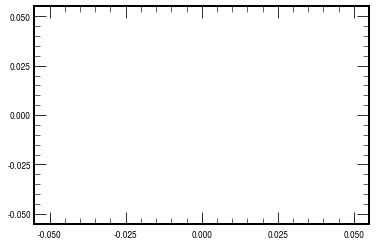

In [4]:
plt.plot()
hep.style.use(hep.style.CMS)

In [5]:
np.set_printoptions(precision=2)

In [6]:
vector.register_awkward()

In [77]:
xrd_path = "root://cmseos.fnal.gov//store/group/lpcsuep/"

# file = nanoevents.NanoEventsFactory.from_root(
#     f"{xrd_path}/Muon_counting_search/SUEPNano_UL18_Nov2024_merged/QCD_Pt-300To470_MuEnrichedPt5_TuneCP5_13TeV-pythia8/merged_0.root",
#     schemaclass=nanoevents.NanoAODSchema,
# )

mS = "1000"
T = "1"
mPhi = "1"
signal_name = f"GluGluToSUEP_T{T}p40_TuneCP5_13TeV_pythia8_split/SUEP_mS{mS}.000_mPhi{mPhi}.400_T{T}.400_modehadronic"
file = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}/Muon_counting_search/SUEPNano_UL18_May2025_merged/{signal_name}/merged_0.root",
    schemaclass=nanoevents.NanoAODSchema,
    # entry_start=0,
    # entry_stop=15000,
)

# file = nanoevents.NanoEventsFactory.from_root(
#     f"{xrd_path}/SUEPNano_data/DoubleMuon+Run2018A-UL2018_MiniAODv2-v1+MINIAOD/9B7DBC31-5038-1948-994A-8175C30AA6AA.root"
# )

events = file.events()

In [78]:
print(len(events))

632

In [79]:
events = events[
    events.HLT.TripleMu_12_10_5
    | events.HLT.TripleMu_10_5_5_DZ
    | events.HLT.TripleMu_5_3_3_Mass3p8_DZ
]

In [80]:
muons = events.Muon[
    (events.Muon.mediumId)
    & (events.Muon.pt > 3)
    & (abs(events.Muon.eta) < 2.4)
    & (abs(events.Muon.dz) < 0.2)
]

In [81]:
enough_muons = ak.num(muons) >= 3
events = events[enough_muons]
muons = muons[enough_muons]

In [82]:
muons1 = muons[muons.charge == 1]
muons2 = muons[muons.charge == -1]
muons1_idx = ak.local_index(muons)[muons.charge == 1]
muons2_idx = ak.local_index(muons)[muons.charge == -1]

In [83]:
print(muons1_idx)  # mu+
print(muons2_idx)  # mu-

[[0, 2], [0, 4, 6, 7], [0, 1, 2, 6], [1, ... [0, 3], [0, 1, 2, 3], [1, 2, 4, 5, 6]]

[[1], [1, 2, 3, 5], [3, 4, 5], [0, 3, 5, ... [3, 4], [1, 2, 4], [], [0, 3, 7, 8]]

In [38]:
enough_muons = (ak.num(muons1) > 0) & (ak.num(muons2) > 0)

In [39]:
muons1 = muons1[enough_muons]
muons2 = muons2[enough_muons]
muons1_idx = muons1_idx[enough_muons]
muons2_idx = muons2_idx[enough_muons]

In [40]:
muons = muons[enough_muons]
events = events[enough_muons]

In [41]:
print(muons1_idx)
print(muons2_idx)

[[0, 1], [0, 2], [0, 2], [0, 2], [0, 3], ... 2], [1, 2], [0, 2], [1], [0, 3], [2]]

[[2], [1], [1], [1, 3], [1, 2], [0, 2], ... [1], [0], [1], [0, 2], [1, 2], [0, 1]]

In [42]:
print(ak.num(muons1_idx), max(ak.num(muons1_idx)))
print(ak.num(muons2_idx), max(ak.num(muons2_idx)))

[2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 1, 3, ... 1, 1, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 1] 5

[1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, ... 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2] 5

In [43]:
muon_pairs = ak.unzip(ak.cartesian([muons1, muons2], nested=False))
muon_pairs_idx = ak.unzip(ak.cartesian([muons1_idx, muons2_idx], nested=False))
muon_pairs_0 = muon_pairs[0]
muon_pairs_1 = muon_pairs[1]
muon_pairs_0_idx = muon_pairs_idx[0]
muon_pairs_1_idx = muon_pairs_idx[1]

In [44]:
print(muon_pairs_0_idx)
print(muon_pairs_1_idx)
print(ak.num(muon_pairs_0_idx), max(ak.num(muon_pairs_0_idx)))
print(ak.num(muon_pairs_1_idx), max(ak.num(muon_pairs_1_idx)))

[[0, 1], [0, 2], [0, 2], [0, 0, 2, 2], ... [0, 2], [1, 1], [0, 0, 3, 3], [2, 2]]

[[2, 2], [1, 1], [1, 1], [1, 3, 1, 3], ... [1, 1], [0, 2], [1, 2, 1, 2], [0, 1]]

[2, 2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 2, 2, 6, ... 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 2] 9

[2, 2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 2, 2, 6, ... 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 2] 9

In [45]:
delta_r = muon_pairs_0.delta_r(muon_pairs_1)
mass = (muon_pairs_0 + muon_pairs_1).mass

In [55]:
print(delta_r)

[[3.01, 4.4], [0.202, 0.512], [0.973, ... 0.567, 0.162, 0.857, 1.21], [0.205, 0.317]]

In [79]:
print(mass)

[[7.06, 3.53, 10.1, 9.34, 2.41], [9.63, ... 12, 4.92, 7.47, 6.96, 6.73, 5.79, 1.39]]

In [80]:
# Optional initial filtering
# pair_filter = (delta_r < 0.6) & (mass < 15)
# muon_pairs_0 = muon_pairs_0[pair_filter]
# muon_pairs_1 = muon_pairs_1[pair_filter]
# muon_pairs_0_idx = muon_pairs_0_idx[pair_filter]
# muon_pairs_1_idx = muon_pairs_1_idx[pair_filter]
# delta_r = delta_r[pair_filter]
# mass = mass[pair_filter]

In [81]:
print(muon_pairs_0_idx)
print(muon_pairs_1_idx)

[[5, 5, 5, 5, 5], [1, 1, 2, 2, 3, 3, 4, 4, ... 6, 6, 6, 6], [0, 0, 0, 0, 4, 4, 4, 4]]

[[0, 1, 2, 3, 4], [0, 5, 0, 5, 0, 5, 0, 5, ... 2, 3, 7, 8], [1, 2, 3, 5, 1, 2, 3, 5]]

In [82]:
print(delta_r)

[[1.36, 0.669, 2.55, 2.47, 0.578], ... 0.981, 1.65, 2.05, 2.12, 2.07, 0.425]]

In [83]:
argmin_delta_r = ak.argmin(delta_r, axis=-1, keepdims=True)
found_pairs_0 = muon_pairs_0[argmin_delta_r]
found_pairs_1 = muon_pairs_1[argmin_delta_r]
found_pairs_0_idx = muon_pairs_0_idx[argmin_delta_r]
found_pairs_1_idx = muon_pairs_1_idx[argmin_delta_r]

In [84]:
print(found_pairs_0_idx)
print(found_pairs_1_idx)

[[5], [3], [2], [3], [4], [2], [0], [3], ... [0], [4], [1], [4], [2], [7], [1], [4]]

[[4], [5], [1], [0], [0], [0], [1], [4], ... [3], [3], [0], [2], [5], [4], [8], [5]]

In [85]:
print(muon_pairs_0_idx)
print(muon_pairs_1_idx)
print(muon_pairs_0_idx[argmin_delta_r])
print(muon_pairs_1_idx[argmin_delta_r])

[[5, 5, 5, 5, 5], [1, 1, 2, 2, 3, 3, 4, 4, ... 6, 6, 6, 6], [0, 0, 0, 0, 4, 4, 4, 4]]

[[0, 1, 2, 3, 4], [0, 5, 0, 5, 0, 5, 0, 5, ... 2, 3, 7, 8], [1, 2, 3, 5, 1, 2, 3, 5]]

[[5], [3], [2], [3], [4], [2], [0], [3], ... [0], [4], [1], [4], [2], [7], [1], [4]]

[[4], [5], [1], [0], [0], [0], [1], [4], ... [3], [3], [0], [2], [5], [4], [8], [5]]

In [90]:
# Remove found pairs
remove_found = (
    muon_pairs_0_idx
    != ak.broadcast_arrays(
        ak.firsts(muon_pairs_0_idx[argmin_delta_r]), muon_pairs_0_idx
    )[0]
) & (
    muon_pairs_1_idx
    != ak.broadcast_arrays(
        ak.firsts(muon_pairs_1_idx[argmin_delta_r]), muon_pairs_1_idx
    )[0]
)

In [95]:
ievt = 1
print(muon_pairs_0_idx[ievt])
print(muon_pairs_1_idx[ievt])
print(muon_pairs_0_idx[argmin_delta_r][ievt])
print(muon_pairs_1_idx[argmin_delta_r][ievt])
print(remove_found[ievt])

[1, 1, 2, 2, 3, 3, 4, 4]

[0, 5, 0, 5, 0, 5, 0, 5]

[3]

[5]

[True, False, True, False, False, False, True, False]

In [96]:
muon_pairs_0 = muon_pairs_0[remove_found]
muon_pairs_1 = muon_pairs_1[remove_found]
muon_pairs_0_idx = muon_pairs_0_idx[remove_found]
muon_pairs_1_idx = muon_pairs_1_idx[remove_found]

In [97]:
print(muon_pairs_0_idx)
print(muon_pairs_1_idx)

[[], [1, 2, 4], [], [1, 1, 1], [2, 2, ... 0, 4, 4, 4, 5, 5, 5, 6, 6, 6], [0, 0, 0]]

[[], [0, 0, 0], [], [2, 4, 5], [1, 3, ... 7, 2, 3, 7, 2, 3, 7, 2, 3, 7], [1, 2, 3]]

In [98]:
delta_r = muon_pairs_0.delta_r(muon_pairs_1)
argmin_delta_r = ak.argmin(delta_r, axis=-1, keepdims=True)

In [99]:
print(delta_r)
print(argmin_delta_r)

[[], [1.78, 2.5, 3.05], [], [1.19, ... 1.4, 0.502, 0.719, 1.91], [3.11, 3.03, 0.981]]

[[None], [0], [None], [1], [0], [None], ... [None], [0], [0], [2], [0], [2]]

In [100]:
temp_found_pairs_0 = muon_pairs_0[argmin_delta_r]
temp_found_pairs_1 = muon_pairs_1[argmin_delta_r]
temp_found_pairs_0_idx = muon_pairs_0_idx[argmin_delta_r]
temp_found_pairs_1_idx = muon_pairs_1_idx[argmin_delta_r]

In [101]:
print(temp_found_pairs_0_idx)
print(temp_found_pairs_1_idx)

[[None], [1], [None], [1], [2], [None], ... [None], [1], [3], [3], [0], [0]]

[[None], [0], [None], [4], [1], [None], ... [None], [0], [0], [0], [2], [3]]

In [104]:
print(found_pairs_0_idx)
print(found_pairs_1_idx)

[[5], [3], [2], [3], [4], [2], [0], [3], ... [0], [4], [1], [4], [2], [7], [1], [4]]

[[4], [5], [1], [0], [0], [0], [1], [4], ... [3], [3], [0], [2], [5], [4], [8], [5]]

In [111]:
found_pairs_0 = ak.concatenate([found_pairs_0, temp_found_pairs_0], axis=-1)
found_pairs_1 = ak.concatenate([found_pairs_1, temp_found_pairs_1], axis=-1)
found_pairs_0_idx = ak.concatenate([found_pairs_0_idx, temp_found_pairs_0_idx], axis=-1)
found_pairs_1_idx = ak.concatenate([found_pairs_1_idx, temp_found_pairs_1_idx], axis=-1)

In [113]:
remove_found = (
    muon_pairs_0_idx
    != ak.broadcast_arrays(
        ak.firsts(muon_pairs_0_idx[argmin_delta_r]), muon_pairs_0_idx
    )[0]
) & (
    muon_pairs_1_idx
    != ak.broadcast_arrays(
        ak.firsts(muon_pairs_1_idx[argmin_delta_r]), muon_pairs_1_idx
    )[0]
)

In [114]:
remove_found

<Array [None, [False, False, ... False, False]] type='22014 * option[var * bool]'>

In [118]:
ak.pad_none(muon_pairs_0_idx, 1)

<Array [[None], [1, 2, 4], ... 6], [0, 0, 0]] type='22014 * option[var * ?int64]'>

In [119]:
muon_pairs_0 = muon_pairs_0[remove_found]
muon_pairs_1 = muon_pairs_1[remove_found]
muon_pairs_0_idx = muon_pairs_0_idx[remove_found]
muon_pairs_1_idx = muon_pairs_1_idx[remove_found]

In [120]:
muon_pairs_0_idx

<Array [None, [], None, [], ... 5, 6, 6], []] type='22014 * option[var * int64]'>

In [74]:
muon_pairs = ak.unzip(ak.cartesian([muons1, muons2], nested=False))
muon_pairs_idx = ak.unzip(ak.cartesian([muons1_idx, muons2_idx], nested=False))
muon_pairs_0 = muon_pairs[0]
muon_pairs_1 = muon_pairs[1]
muon_pairs_0_idx = muon_pairs_idx[0]
muon_pairs_1_idx = muon_pairs_idx[1]
found_pairs_0 = ak.copy(muon_pairs_0)[ak.local_index(muon_pairs_0) < 0]
found_pairs_1 = ak.copy(muon_pairs_1)[ak.local_index(muon_pairs_1) < 0]
found_pairs_0_idx = ak.copy(muon_pairs_0_idx)[ak.local_index(muon_pairs_0_idx) < 0]
found_pairs_1_idx = ak.copy(muon_pairs_1_idx)[ak.local_index(muon_pairs_1_idx) < 0]
i_iter = 0
while not all(ak.is_none(muon_pairs_0_idx)):
    # print(f"Performing iteration {i_iter}...")
    i_iter += 1
    delta_r = muon_pairs_0.delta_r(muon_pairs_1)
    argmin_delta_r = ak.argmin(delta_r, axis=-1, keepdims=True)
    temp_found_pairs_0 = muon_pairs_0[argmin_delta_r]
    temp_found_pairs_1 = muon_pairs_1[argmin_delta_r]
    temp_found_pairs_0_idx = muon_pairs_0_idx[argmin_delta_r]
    temp_found_pairs_1_idx = muon_pairs_1_idx[argmin_delta_r]
    found_pairs_0 = ak.concatenate([found_pairs_0, temp_found_pairs_0], axis=-1)
    found_pairs_1 = ak.concatenate([found_pairs_1, temp_found_pairs_1], axis=-1)
    found_pairs_0_idx = ak.concatenate(
        [found_pairs_0_idx, temp_found_pairs_0_idx], axis=-1
    )
    found_pairs_1_idx = ak.concatenate(
        [found_pairs_1_idx, temp_found_pairs_1_idx], axis=-1
    )
    remove_found = (
        muon_pairs_0_idx
        != ak.broadcast_arrays(
            ak.firsts(muon_pairs_0_idx[argmin_delta_r]), muon_pairs_0_idx
        )[0]
    ) & (
        muon_pairs_1_idx
        != ak.broadcast_arrays(
            ak.firsts(muon_pairs_1_idx[argmin_delta_r]), muon_pairs_1_idx
        )[0]
    )
    muon_pairs_0 = muon_pairs_0[remove_found]
    muon_pairs_1 = muon_pairs_1[remove_found]
    muon_pairs_0_idx = muon_pairs_0_idx[remove_found]
    muon_pairs_1_idx = muon_pairs_1_idx[remove_found]
found_pairs_0_old = found_pairs_0[~ak.is_none(found_pairs_0, axis=-1)]
found_pairs_1_old = found_pairs_1[~ak.is_none(found_pairs_1, axis=-1)]
found_pairs_0_idx_old = found_pairs_0_idx[~ak.is_none(found_pairs_0_idx, axis=-1)]
found_pairs_1_idx_old = found_pairs_1_idx[~ak.is_none(found_pairs_1_idx, axis=-1)]
print(len(found_pairs_0_idx_old))
print(len(found_pairs_0_idx_old))
print(found_pairs_0_idx_old)
print(found_pairs_1_idx_old)

15983

15983

[[0, 3, 8, 1], [0, 2, 8, 6, 7, 9], [3, 6, ... 3, 0, 1], [4, 13, 6, 10, 5], [3, 4, 5]]

[[4, 5, 6, 2], [5, 3, 1, 12, 4, 10], [2, ... 5, 2, 6], [2, 0, 9, 7, 12], [0, 6, 7]]

In [84]:
muon_pairs = ak.unzip(ak.cartesian([muons1, muons2], nested=False))
muon_pairs_idx = ak.unzip(ak.cartesian([muons1_idx, muons2_idx], nested=False))
muon_pairs_0, muon_pairs_1 = muon_pairs
muon_pairs_0_idx, muon_pairs_1_idx = muon_pairs_idx

found_0, found_1, idx_0, idx_1 = [], [], [], []

itr = 0
while ak.any(ak.num(muon_pairs_0) > 0):
    print(itr)
    itr += 1
    delta_r = muon_pairs_0.delta_r(muon_pairs_1)
    argmin_delta_r = ak.argmin(delta_r, axis=-1, keepdims=True)

    temp_0 = muon_pairs_0[argmin_delta_r]
    temp_1 = muon_pairs_1[argmin_delta_r]
    temp_0_idx = muon_pairs_0_idx[argmin_delta_r]
    temp_1_idx = muon_pairs_1_idx[argmin_delta_r]

    found_0.append(temp_0)
    found_1.append(temp_1)
    idx_0.append(temp_0_idx)
    idx_1.append(temp_1_idx)

    matched_0 = ak.firsts(temp_0_idx)
    matched_1 = ak.firsts(temp_1_idx)

    remove_mask = (muon_pairs_0_idx != matched_0) & (muon_pairs_1_idx != matched_1)
    muon_pairs_0 = muon_pairs_0[remove_mask]
    muon_pairs_1 = muon_pairs_1[remove_mask]
    muon_pairs_0_idx = muon_pairs_0_idx[remove_mask]
    muon_pairs_1_idx = muon_pairs_1_idx[remove_mask]

    if ak.all(ak.num(muon_pairs_0) == 0):
        break

# Combine results
if found_0:
    found_pairs_0 = ak.concatenate(found_0, axis=-1)
    found_pairs_1 = ak.concatenate(found_1, axis=-1)
    found_pairs_0_idx = ak.concatenate(idx_0, axis=-1)
    found_pairs_1_idx = ak.concatenate(idx_1, axis=-1)
else:
    # Handle case with no OS pairs anywhere
    found_pairs_0 = ak.Array([[]] * len(muons))
    found_pairs_1 = ak.Array([[]] * len(muons))
    found_pairs_0_idx = ak.Array([[]] * len(muons))
    found_pairs_1_idx = ak.Array([[]] * len(muons))

# Ensure the same number of events as input (important!)
found_pairs_0 = ak.fill_none(found_pairs_0, [], axis=0)
found_pairs_1 = ak.fill_none(found_pairs_1, [], axis=0)
found_pairs_0_idx = ak.fill_none(found_pairs_0_idx, [], axis=0)
found_pairs_1_idx = ak.fill_none(found_pairs_1_idx, [], axis=0)

found_pairs_0_new = found_pairs_0[~ak.is_none(found_pairs_0, axis=-1)]
found_pairs_1_new = found_pairs_1[~ak.is_none(found_pairs_1, axis=-1)]
found_pairs_0_idx_new = found_pairs_0_idx[~ak.is_none(found_pairs_0_idx, axis=-1)]
found_pairs_1_idx_new = found_pairs_1_idx[~ak.is_none(found_pairs_1_idx, axis=-1)]

print(len(found_pairs_0_idx_new))
print(found_pairs_0_idx_new)
print(found_pairs_1_idx_new)

0

1

2

3

4

...

8

9

632

[[2], [6, 0, 7, 4], [6, 1, 2], [2, 1, 4], ... [], [2, 0], [0, 3], [], [5, 2, 6, 1]]

[[1], [5, 2, 3, 1], [3, 5, 4], [3, 5, 0], ... [], [3, 4], [1, 2], [], [0, 7, 3, 8]]

In [76]:
all(ak.all(found_pairs_0_idx_new == found_pairs_0_idx_old, axis=-1))

True

In [88]:
found_pairs_0_new[-2:-1].delta_r(found_pairs_1_new[-2:-1])

<Array [[]] type='1 * var * ?float32'>

In [72]:
# Found muon pairs
print(found_pairs_0_idx)
print(found_pairs_1_idx)
print(found_pairs_0.delta_r(found_pairs_1))
print((found_pairs_0 + found_pairs_1).mass)

[[0, 4, 2], [0, 7, 2], [4, 3, 6], [3, 5, ... [0, 7, 2, 10, 12], [1, 4, 0], [6, 5, 0]]

[[5, 7, 8], [5, 6, 4], [0, 5, 1], [0, 2, ... [11, 1, 9, 8, 6], [3, 5, 2], [1, 2, 3]]

[[0.033, 0.0657, 1.46], [0.0383, 0.084, ... 0.155, 2.59], [0.0679, 0.0905, 1.64]]

[[0.709, 0.692, 11.6], [0.651, 0.499, 2.4, ... 0.699, 16], [0.704, 0.705, 20.6]]

In [73]:
# Original muon pairs
muon_pairs = ak.unzip(ak.cartesian([muons1, muons2], nested=False))
muon_pairs_idx = ak.unzip(ak.cartesian([muons1_idx, muons2_idx], nested=False))
muon_pairs_0 = muon_pairs[0]
muon_pairs_1 = muon_pairs[1]
muon_pairs_0_idx = muon_pairs_idx[0]
muon_pairs_1_idx = muon_pairs_idx[1]
print(muon_pairs_0_idx)
print(muon_pairs_1_idx)
print(muon_pairs_0.delta_r(muon_pairs_1))

[[0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 4, 4, ... [0, 0, 0, 0, 5, 5, 5, 5, 6, 6, 6, 6]]

[[1, 3, 5, 6, 7, 8, 1, 3, 5, 6, 7, 8, 1, 3, ... [1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4]]

[[1.29, 1.07, 0.033, 1.09, 0.61, 1.62, ... 1.71, 0.422, 0.0679, 1.03, 2.43, 1.29]]

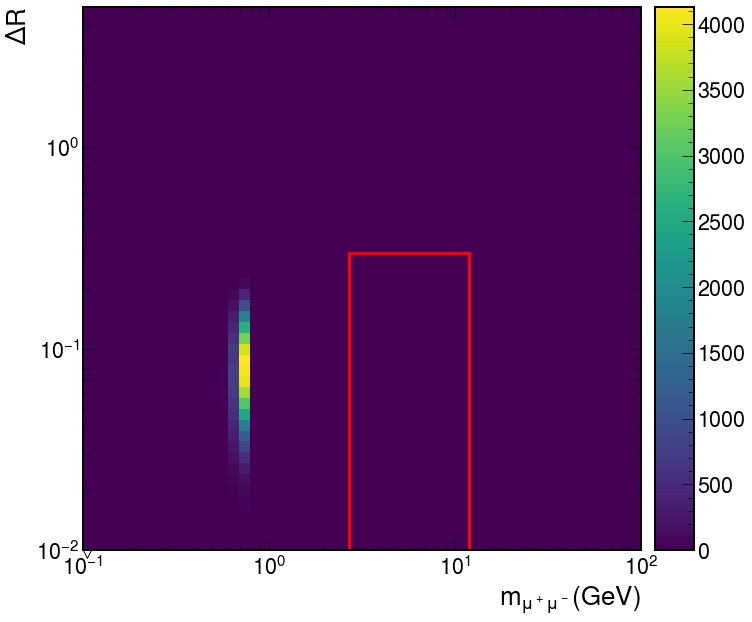

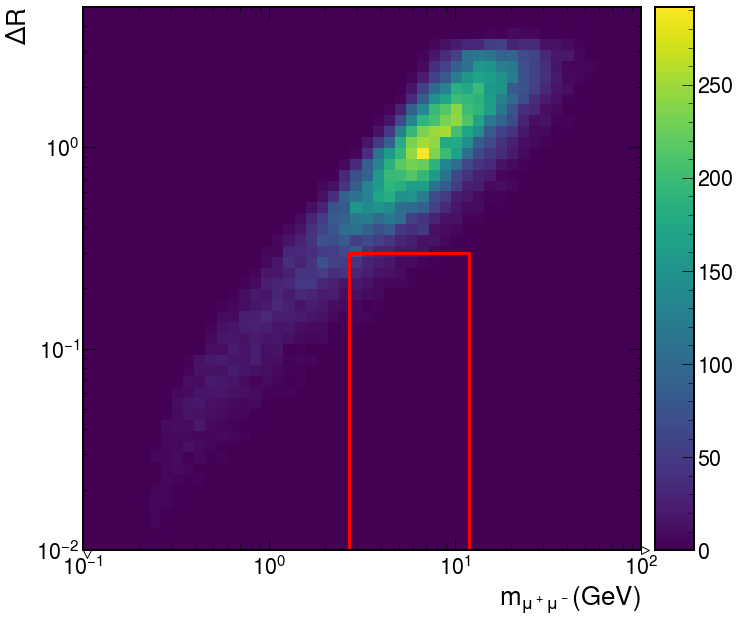

In [74]:
# Let's compare dR and mass for pairs from same parent vs different
same_parent_mask = (
    found_pairs_0.matched_gen.distinctParentIdxG
    == found_pairs_1.matched_gen.distinctParentIdxG
) & (found_pairs_0.matched_gen.distinctParentIdxG >= 0)
same_parent_mask = ak.fill_none(same_parent_mask, False)

dR = found_pairs_0.delta_r(found_pairs_1)
mass = (found_pairs_0 + found_pairs_1).mass

h1 = (
    hist.Hist.new.Reg(50, 0.1, 100, name="mass", transform=hist.axis.transform.log)
    .Reg(50, 0.01, 5, name="dR", transform=hist.axis.transform.log)
    .Double()
)
h1.fill(ak.flatten(mass[same_parent_mask]), ak.flatten(dR[same_parent_mask]))
h2 = (
    hist.Hist.new.Reg(50, 0.1, 100, name="mass", transform=hist.axis.transform.log)
    .Reg(50, 0.01, 5, name="dR", transform=hist.axis.transform.log)
    .Double()
)
h2.fill(ak.flatten(mass[~same_parent_mask]), ak.flatten(dR[~same_parent_mask]))

# h1[::sum, :].plot(label="same parent")
# h2[::sum, :].plot(label="different parent")
# plt.legend()
# plt.xlabel("$\Delta R$")
# plt.ylabel("$\mu^+\mu^-$ pairs")
# plt.xscale('log')
# # plt.yscale('log')
# plt.show()

# h1[:, ::sum].plot(label="same parent")
# h2[:, ::sum].plot(label="different parent")
# plt.legend()
# plt.xlabel("$m_{\mu^+\mu^-}$(GeV)")
# plt.ylabel("$\mu^+\mu^-$ pairs")
# plt.xscale('log')
# # plt.yscale('log')
# plt.show()

h1.plot2d(label="same parent")
plt.plot([2.7, 12], [0.3, 0.3], color="red", lw=3)
plt.plot([2.7, 2.7], [0, 0.3], color="red", lw=3)
plt.plot([12, 12], [0, 0.3], color="red", lw=3)
plt.xlabel("$m_{\mu^+\mu^-}$(GeV)")
plt.ylabel("$\Delta R$")
plt.xscale("log")
plt.yscale("log")
plt.show()

h2.plot2d(label="different parent")
plt.plot([2.7, 12], [0.3, 0.3], color="red", lw=3)
plt.plot([2.7, 2.7], [0, 0.3], color="red", lw=3)
plt.plot([12, 12], [0, 0.3], color="red", lw=3)
plt.xlabel("$m_{\mu^+\mu^-}$(GeV)")
plt.ylabel("$\Delta R$")
plt.xscale("log")
plt.yscale("log")
plt.show()

In [26]:
found_pairs_0

<MuonArray [[Muon], [Muon], ... Muon], [Muon]] type='76501 * var * ?muon'>

In [62]:
dr_cut = 0.3
mass_cut = 2.7
same_parent_mask = (
    found_pairs_0.matched_gen.distinctParentIdxG
    == found_pairs_1.matched_gen.distinctParentIdxG
) & (found_pairs_0.matched_gen.distinctParentIdxG >= 0)
same_parent_mask = ak.fill_none(same_parent_mask, False)
dr_mask = found_pairs_0.delta_r(found_pairs_1) < dr_cut
mass_mask = ((found_pairs_0 + found_pairs_1).mass > mass_cut) & (
    (found_pairs_0 + found_pairs_1).mass < 14
)
temp_pairs_0 = found_pairs_0[dr_mask & mass_mask & same_parent_mask]
temp_pairs_0 = temp_pairs_0[ak.num(temp_pairs_0) > 0]
print(f"dr cut: {dr_cut}")
print(f"mass cut: {mass_cut}")
print(
    f"Fraction of rejected same parent dimuon pairs: {len(ak.flatten(temp_pairs_0))/len(ak.flatten(found_pairs_0[same_parent_mask]))}"
)

dr cut: 0.3

mass cut: 2.7

Fraction of rejected same parent dimuon pairs: 0.2906674371568911

In [61]:
dr_cut = 0.3
mass_cut = 2.7
dr_mask = found_pairs_0.delta_r(found_pairs_1) < dr_cut
mass_mask = ((found_pairs_0 + found_pairs_1).mass > mass_cut) & (
    (found_pairs_0 + found_pairs_1).mass < 14
)
temp_pairs_0 = found_pairs_0[dr_mask & mass_mask]
temp_pairs_1 = found_pairs_1[dr_mask & mass_mask]
temp_pairs_0 = temp_pairs_0[ak.num(temp_pairs_0) > 0]
temp_pairs_1 = temp_pairs_1[ak.num(temp_pairs_1) > 0]
print(f"dr cut: {dr_cut}")
print(f"mass cut: {mass_cut}")
print(f"Efficiency: {(1 - len(temp_pairs_0)/len(found_pairs_0))}")

dr cut: 0.3

mass cut: 2.7

Efficiency: 0.9155435876655207

In [30]:
dr_cuts = np.linspace(0.1, 0.8, 20)
mass_cuts = np.linspace(1, 5, 20)
sig_eff = []
for dr_cut in track(dr_cuts):
    dr_mask = found_pairs_0.delta_r(found_pairs_1) < dr_cut
    sig_eff_dr = []
    for mass_cut in mass_cuts:
        mass_mask = ((found_pairs_0 + found_pairs_1).mass > mass_cut) & (
            (found_pairs_0 + found_pairs_1).mass < 14
        )
        temp_pairs_0 = found_pairs_0[dr_mask & mass_mask]
        temp_pairs_1 = found_pairs_1[dr_mask & mass_mask]
        temp_pairs_0 = temp_pairs_0[ak.num(temp_pairs_0) > 0]
        temp_pairs_1 = temp_pairs_1[ak.num(temp_pairs_1) > 0]
        sig_eff_dr.append((1 - len(temp_pairs_0) / len(found_pairs_0)))
    sig_eff.append(sig_eff_dr)

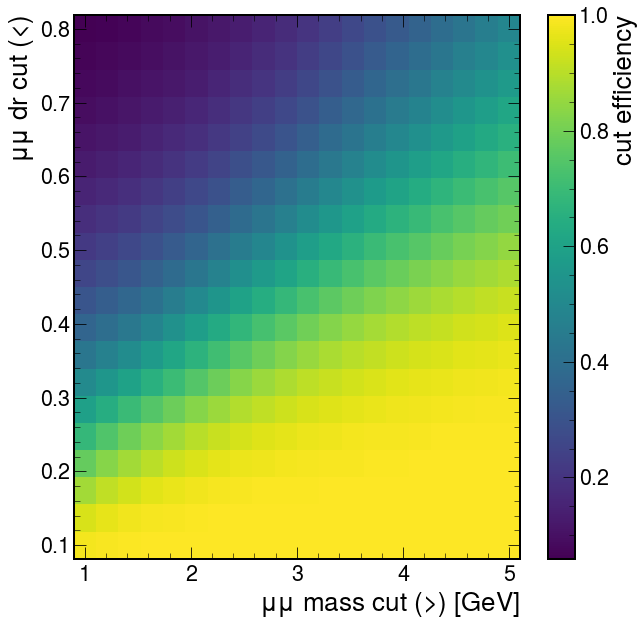

In [31]:
plt.pcolormesh(mass_cuts, dr_cuts, sig_eff)
plt.colorbar(label="cut efficiency")
plt.xlabel(r"$\mu\mu$ mass cut (>) [GeV]")
plt.ylabel(r"$\mu\mu$ dr cut (<)")
plt.show()

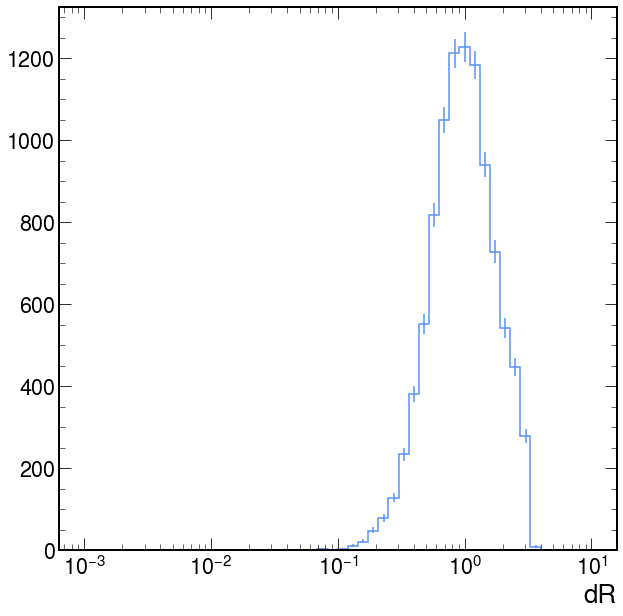

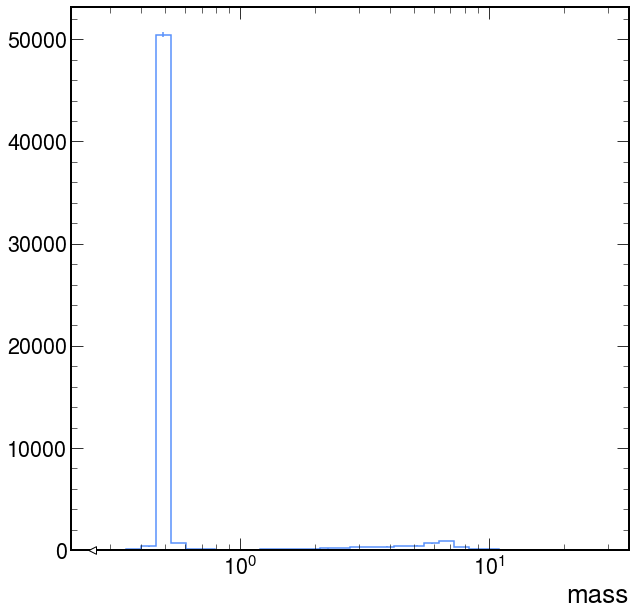

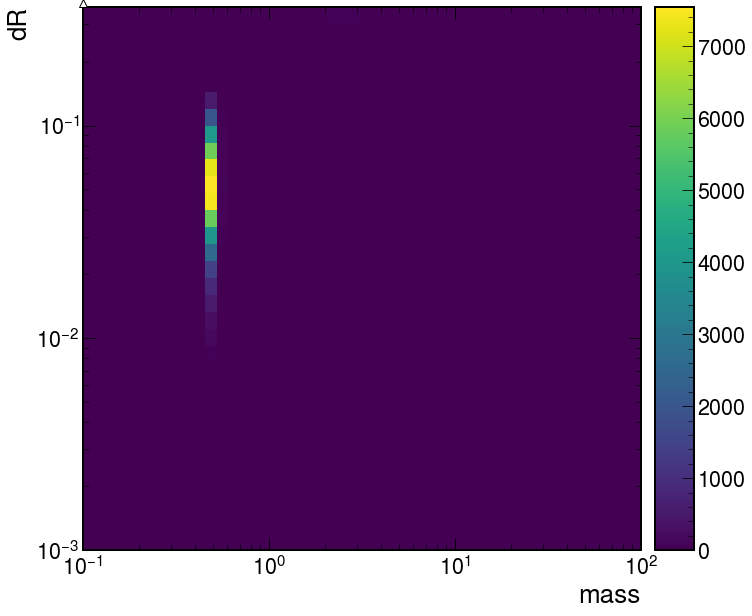

In [88]:
h = (
    hist.Hist.new.Reg(50, 0.1, 100, name="mass", transform=hist.axis.transform.log)
    .Reg(50, 0.001, 10, name="dR", transform=hist.axis.transform.log)
    .Double()
)
h.fill(
    ak.flatten((found_pairs_0 + found_pairs_1).mass),
    ak.flatten(found_pairs_0.delta_r(found_pairs_1)),
)

# h[::sum, :].plot()
h[2j:14j:sum, :].plot()
plt.xscale("log")
# plt.yscale('log')
plt.show()

# h[0.3j:30j, ::sum].plot()
h[0.3j:30j, :1j:sum].plot()
plt.xscale("log")
# plt.yscale('log')
plt.show()

h[:, :0.4j].plot2d()
plt.xscale("log")
plt.yscale("log")
plt.show()